In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_read = pd.read_csv('exercise_dataset.csv')
df_read.head()

,name,target,bodyPart,equipment
0,lever seated hip abduction,abductors,upper legs,leverage machine
1,side hip abduction,abductors,upper legs,body weight
2,straight leg outer hip abductor,abductors,upper legs,body weight
3,side bridge hip abduction,abductors,upper legs,body weight
4,resistance band seated hip abduction,abductors,upper legs,resistance band


In [3]:
df_read.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       168 non-null    str  
 1   target     168 non-null    str  
 2   bodyPart   168 non-null    str  
 3   equipment  168 non-null    str  
dtypes: str(4)
memory usage: 5.4 KB


In [4]:
df_read.isnull().sum()

name         0
target       0
bodyPart     0
equipment    0
dtype: int64

In [5]:
df_read.columns

Index(['name', 'target', 'bodyPart', 'equipment'], dtype='str')

In [6]:
df_read["name"].unique()

<StringArray>
[                     'lever seated hip abduction',
                              'side hip abduction',
                 'straight leg outer hip abductor',
                       'side bridge hip abduction',
            'resistance band seated hip abduction',
                                      '3/4 sit-up',
                                   '45° side bend',
                                        'air bike',
                         'alternate heel touchers',
     'assisted hanging knee raise with throw down',
 ...
                           'barbell bent over row',
                             'barbell incline row',
                   'barbell one arm bent over row',
              'barbell reverse grip bent over row',
              'cable decline seated wide-grip row',
                'cable floor seated wide-grip row',
                       'cable high row (kneeling)',
                            'cable low seated row',
                     'cable one arm bent over

In [7]:
df_read["target"].unique()

<StringArray>
[            'abductors',                   'abs',             'adductors',
                'biceps',                'calves', 'cardiovascular system',
                 'delts',              'forearms',                'glutes',
            'hamstrings',                  'lats',      'levator scapulae',
             'pectorals',                 'quads',     'serratus anterior',
                 'spine',                 'traps',               'triceps',
            'upper back']
Length: 19, dtype: str

In [8]:
df_read["bodyPart"].unique()

<StringArray>
['upper legs',      'waist', 'upper arms', 'lower legs',     'cardio',
  'shoulders', 'lower arms',       'back',       'neck',      'chest']
Length: 10, dtype: str

In [9]:
df_read["equipment"].unique()

<StringArray>
[  'leverage machine',        'body weight',    'resistance band',
           'assisted',      'medicine ball',            'barbell',
              'cable',           'dumbbell',    'stationary bike',
 'elliptical machine',   'stepmill machine',         'kettlebell',
      'smith machine',           'weighted',               'band',
     'stability ball',   'assisted (towel)']
Length: 17, dtype: str

In [10]:
compound_keywords = [
    'press', 'squat', 'deadlift', 'row', 'pull-up', 'pullup', 'dip', 'clean', 
    'lunge', 'snatch', 'burpee', 'push-up', 'pushup', 'bench', 'pulldown'
]

isolation_keywords = [
    'curl', 'extension', 'abduction', 'adduction', 'raise', 'fly', 'shrug', 
    'kickback', 'stretch', 'twist', 'rotation', 'bend', 'hyper', 'circle'
]

In [11]:
def determine_exercise_type(name):
    name = name.lower()

    if any(word in name for word in compound_keywords):
        return "Compound"

    elif any(word in name for word in isolation_keywords):
        return "Isolation"

    elif any(word in name for word in ["run", "bike", "walk", "climb", "elliptical"]):
        return "Cardio"
        
    else:
        return "Other"

df_read["exercise_type"] = df_read["name"].apply(determine_exercise_type)

In [12]:
df_read["exercise_type"]

0      Isolation
1      Isolation
2          Other
3      Isolation
4      Isolation
         ...    
163     Compound
164     Compound
165     Compound
166     Compound
167     Compound
Name: exercise_type, Length: 168, dtype: str

In [13]:
def determine_mechanics(name):
    name = name.lower()
    push_words = ["press", "extension", "dip", "squat", "lunge", "push-up", "raise"]
    pull_words = ["row", "curl", "pull-up", "pulldown", "deadlift", "shrug"]
    
    if any(word in name for word in push_words):
        return "Push"
    elif any(word in name for word in pull_words):
        return "Pull"
    else:
        return "Other"

df_read["mechanics"] = df_read["name"].apply(determine_mechanics)

In [14]:
df_read["mechanics"]

0      Other
1      Other
2      Other
3      Other
4      Other
       ...  
163     Pull
164     Pull
165     Pull
166     Pull
167     Pull
Name: mechanics, Length: 168, dtype: str

In [15]:
def estimate_difficulty(row):
    score = 0
    if row["equipment"] in ["barbell", "kettlebell"]:
        score += 2
        
    elif row["equipment"] in ["dumbbell", "cable", "leverage machine"]:
        score += 1
    
    if row["exercise_type"] == "Compound":
        score += 1
        
    return score if score > 0 else 1

df_read["difficulty_level"] = df_read.apply(estimate_difficulty, axis=1)

In [16]:
df_read["difficulty_level"]

0      1
1      1
2      1
3      1
4      1
      ..
163    2
164    2
165    2
166    2
167    2
Name: difficulty_level, Length: 168, dtype: int64

In [17]:
print(df_read['exercise_type'].value_counts())
print("-" * 30)
print("Others:")
print(df_read[df_read['exercise_type'] == 'Other']['name'].unique())


exercise_type
Isolation    73
Compound     68
Other        19
Cardio        8
Name: count, dtype: int64
------------------------------
Others:
<StringArray>
[   'straight leg outer hip abductor',                         '3/4 sit-up',
            'alternate heel touchers',                      'barbell skier',
           'dumbbell lying pronation',          'dumbbell lying supination',
     'barbell lying lifting (on hip)',           'assisted prone hamstring',
               'barbell good morning',             'dumbbell lying femoral',
                       'kick out sit',  'barbell decline bent arm pullover',
 'barbell decline wide-grip pullover',                   'barbell pullover',
             'cable incline pushdown',         'cable cross-over variation',
                      'balance board',            'incline scapula push up',
          'kettlebell sumo high pull']
Length: 19, dtype: str


In [18]:
compound_keywords = [
    "press", "squat", "deadlift", "row", "pull-up", "pullup", "dip", "clean", 
    "lunge", "snatch", "burpee", "push-up", "pushup", "bench", "pulldown",
    "high pull", "lifting", "push up"
]

isolation_keywords = [
    "curl", "extension", "abduction", "adduction", "raise", "fly", "shrug", 
    "kickback", "stretch", "twist", "rotation", "bend", "hyper", "circle",
    "sit-up", "toucher", "abductor", "pronation", "supination", "pullover",
    "good morning", "femoral", "hamstring", "skier", "cross-over", "pushdown"
]
df_read["exercise_type"] = df_read["name"].apply(determine_exercise_type)
df_read["mechanics"] = df_read["name"].apply(determine_mechanics)
df_read["difficulty_level"] = df_read.apply(estimate_difficulty, axis=1)

In [19]:
print(df_read['exercise_type'].value_counts())
print("-" * 30)
print("Others:")
print(df_read[df_read['exercise_type'] == 'Other']['name'].unique())

exercise_type
Isolation    87
Compound     71
Cardio        8
Other         2
Name: count, dtype: int64
------------------------------
Others:
<StringArray>
['kick out sit', 'balance board']
Length: 2, dtype: str


In [20]:
df_read

,name,target,bodyPart,equipment,exercise_type,mechanics,difficulty_level
0,lever seated hip abduction,abductors,upper legs,leverage machine,Isolation,Other,1
1,side hip abduction,abductors,upper legs,body weight,Isolation,Other,1
2,straight leg outer hip abductor,abductors,upper legs,body weight,Isolation,Other,1
3,side bridge hip abduction,abductors,upper legs,body weight,Isolation,Other,1
4,resistance band seated hip abduction,abductors,upper legs,resistance band,Isolation,Other,1
...,...,...,...,...,...,...,...
163,cable floor seated wide-grip row,upper back,back,cable,Compound,Pull,2
164,cable high row (kneeling),upper back,back,cable,Compound,Pull,2
165,cable low seated row,upper back,back,cable,Compound,Pull,2
166,cable one arm bent over row,upper back,back,cable,Compound,Pull,2


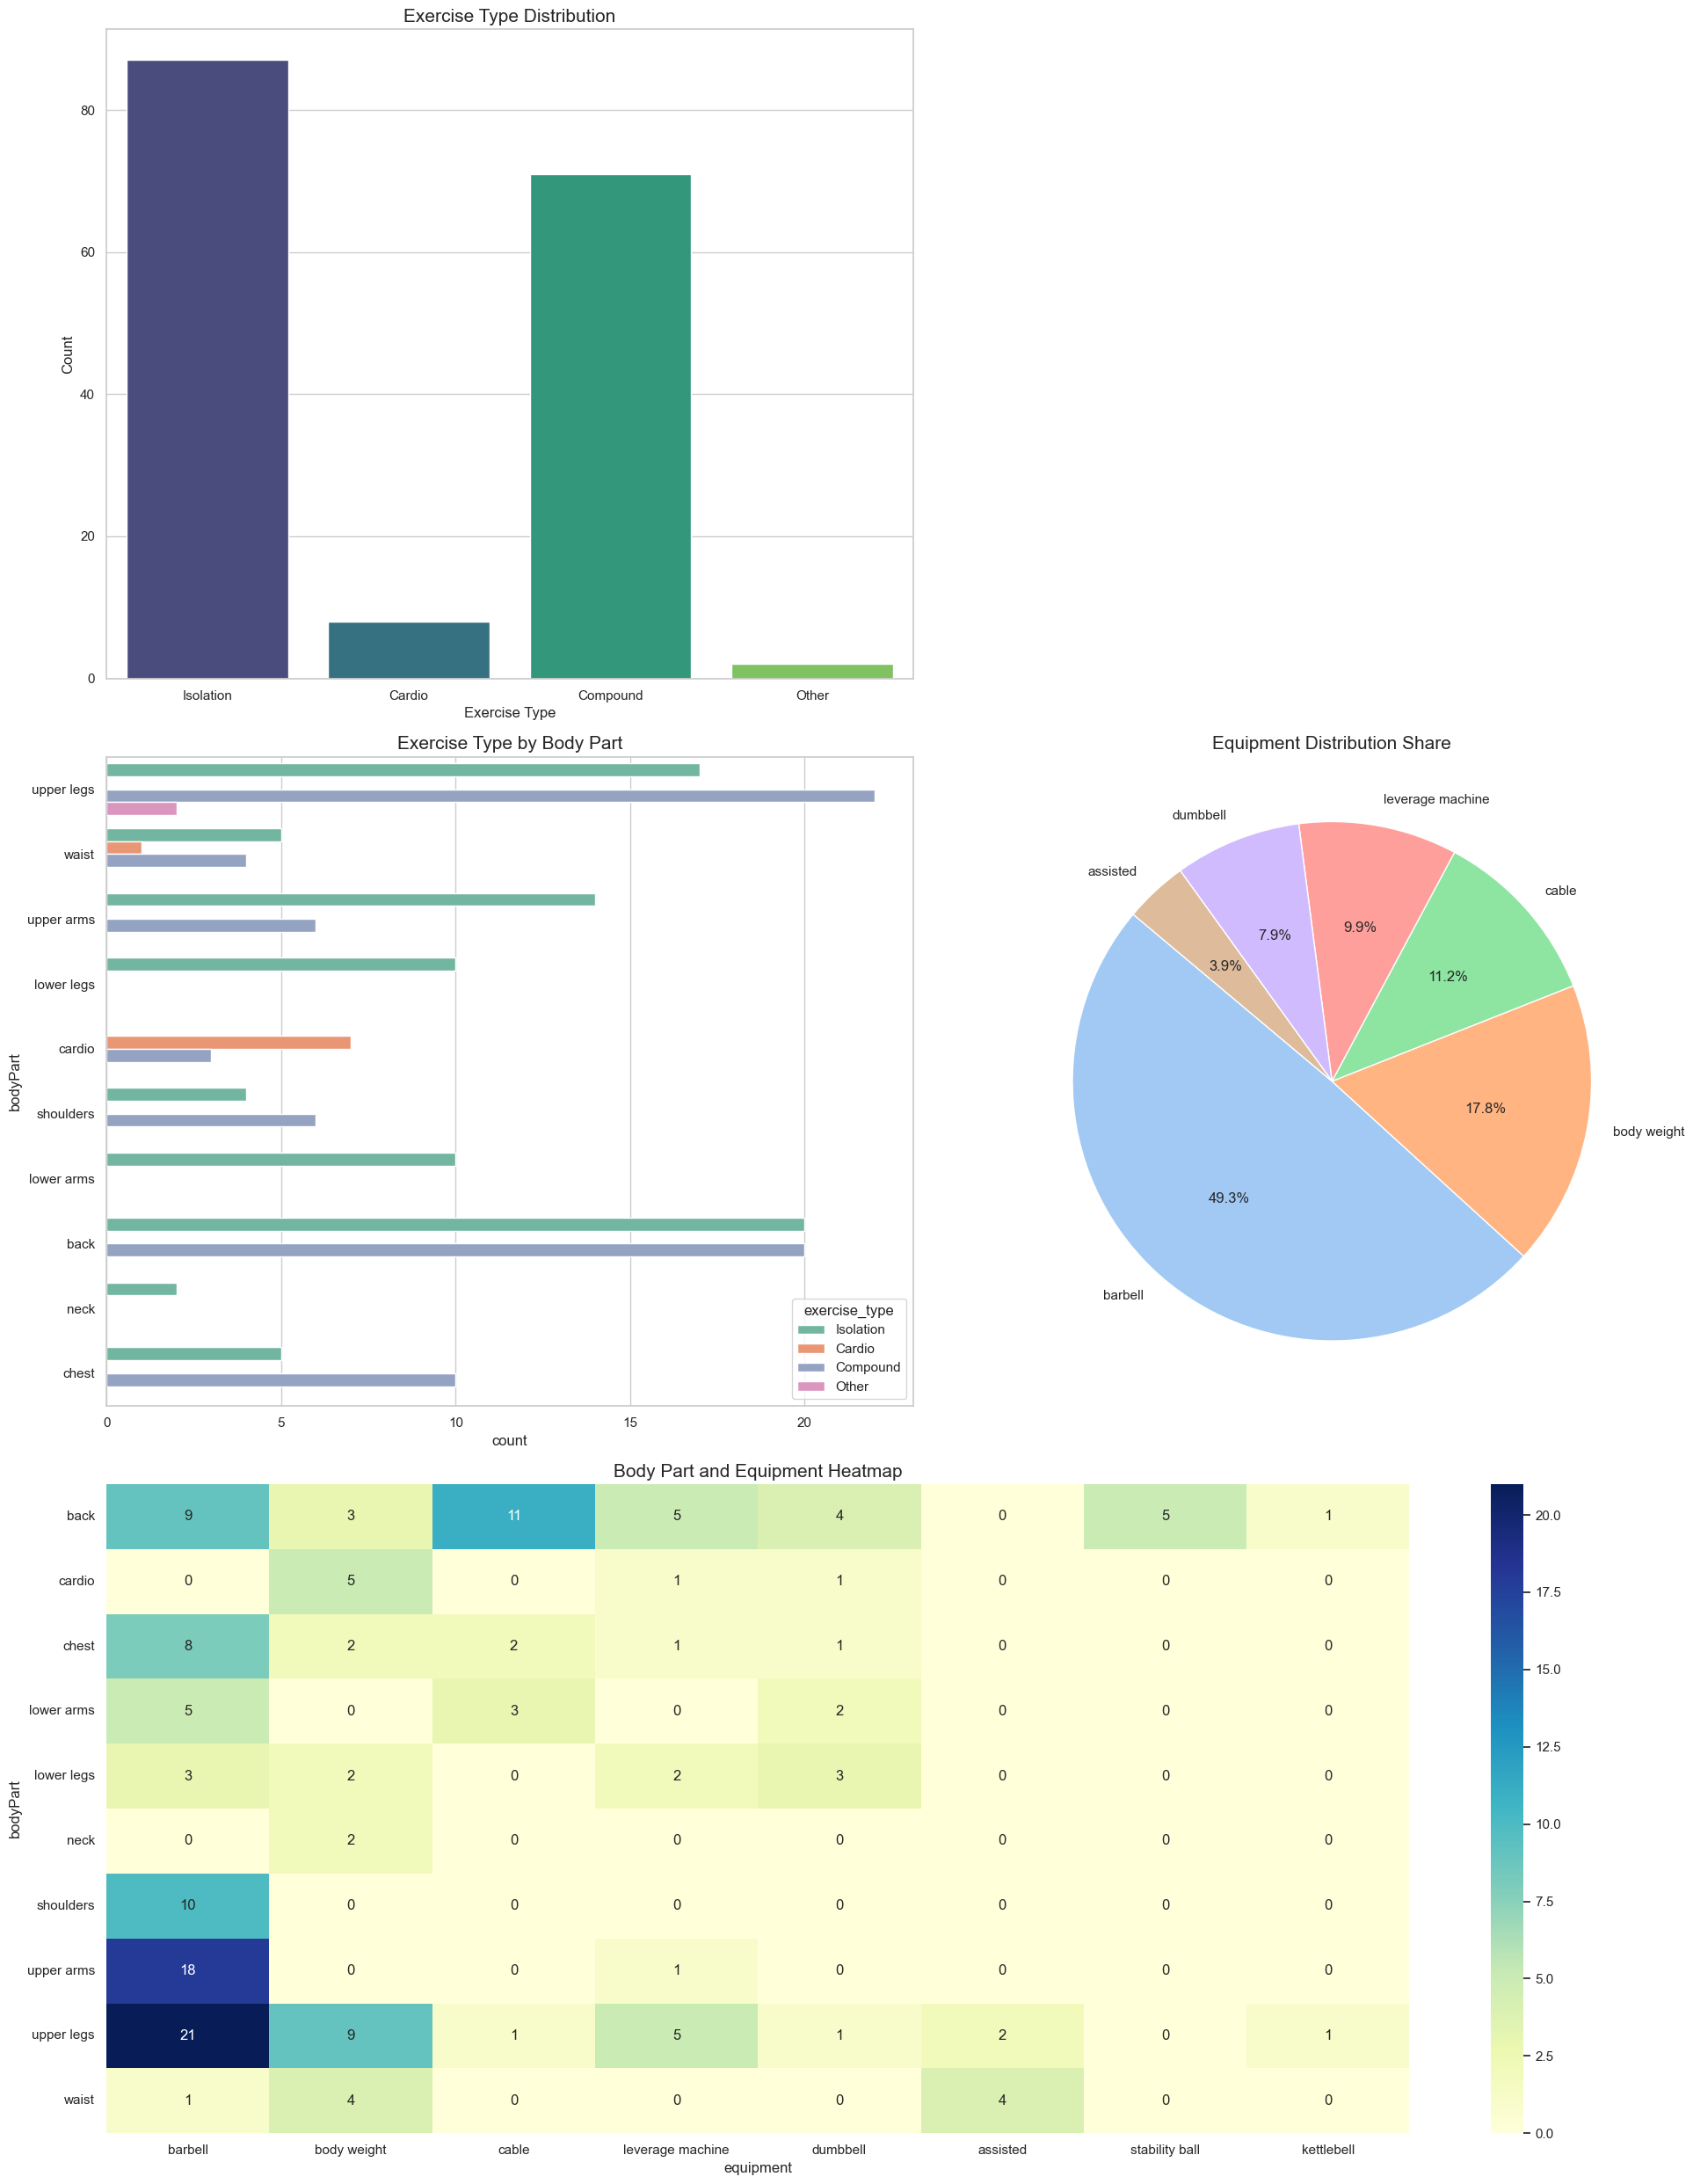

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 25))

plt.subplot(3, 2, 1)
sns.countplot(data=df_read, x="exercise_type", palette="viridis")
plt.title("Exercise Type Distribution", fontsize=15)
plt.xlabel("Exercise Type")
plt.ylabel("Count")

plt.subplot(3, 2, 3)
sns.countplot(data=df_read, y="bodyPart", hue="exercise_type", palette="Set2")
plt.title("Exercise Type by Body Part", fontsize=15)

plt.subplot(3, 2, 4)
equipment_counts = df_read["equipment"].value_counts().head(6)
plt.pie(equipment_counts, labels=equipment_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Equipment Distribution Share", fontsize=15)

plt.subplot(3, 2, (5, 6))
pivot_table = pd.crosstab(df_read["bodyPart"], df_read["equipment"])
top_equip = df_read["equipment"].value_counts().head(8).index
sns.heatmap(pivot_table[top_equip], annot=True, cmap="YlGnBu", fmt="d")
plt.title("Body Part and Equipment Heatmap", fontsize=15)

plt.tight_layout()
plt.savefig("exercise_analysis.png", dpi=300)
plt.show()